In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 경로 설정
import os 
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12,6)

# 시드 설정
np.random.seed(42)

print('-' * 60)
print('라이브러리 로드 완료')
print('한글 폰트 설정 완료!')
print('-'* 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [2]:
#df = pd.read_csv(r'C:\Users\chanhyeok\Desktop\lucky7\airbnb_price_prediction\data\df_cleaned.csv')
#df.head()

# 현재 작업 디렉토리(notebooks)의 부모 디렉토리(root)를 경로에 추가
os.chdir(os.path.abspath('..'))
print(os.getcwd())

df = pd.read_csv('data/df_cleaned.csv')
df.head()

c:\Users\chanhyeok\Desktop\lucky7\airbnb_price_prediction


,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_verifications_email,host_verifications_phone,host_verifications_work_email,log_price,log_estimated_revenue_l365d
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",I’m an urban planner working for an internatio...,NaN,NaN,NaN,False,Prospect Heights,1.0,3.0,True,True,Neighborhood highlights,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200.0,90,365,90.0,90.0,365.0,365.0,90.0,365.0,True,27,57,87,362,9,0,0,301,0,0,0.0,2010-12-11,2013-05-10,4.88,5.00,4.80,5.00,5.00,5.00,5.00,NaN,False,1,0,1,0,0.05,1,1,1,5.303305,0.000000
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",NaN,NaN,NaN,1.00,False,East Harlem,1.0,1.0,True,True,Neighborhood highlights,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1 private bath,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82.0,30,999,30.0,30.0,999.0,999.0,30.0,999.0,True,0,0,0,204,102,0,0,143,0,0,0.0,2010-10-04,2023-12-09,4.77,4.82,4.76,4.88,4.90,4.38,4.71,NaN,False,1,0,1,0,0.58,1,1,0,4.418841,0.000000
2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",I am a lawyer and work as an executive at an a...,within a few hours,1.0,0.40,False,Boerum Hill,1.0,3.0,True,True,Neighborhood highlights,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765.0,3,60,3.0,3.0,60.0,60.0,3.0,60.0,True,30,49,66,326,43,0,0,267,0,0,0.0,2012-07-09,2023-08-30,4.70,4.83,4.52,4.88,4.88,4.86,4.62,OSE-STRREG-0001784,False,1,0,1,0,0.28,1,1,1,6.641182,0.000000
3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,West Harlem is now packed with great restauran...,166532,Matthew,2010-07-14,"New York, NY",I have been a New Yorker for a long time\n and...,within an hour,1.0,0.97,True,Harlem,1.0,1.0,True,True,Neighborhood highlights,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",139.0,2,45,2.0,2.0,1125.0,1125.0,2.0,1125.0,True,7,18,25,25,241,42,3,25,43,255,35445.0,2010-08-28,2025-02-21,4.85,4.87,4.50,4.96,4.96,4.79,4.82,OSE-STRREG-0000476,False,1,1,0,0,1.36,1,1,0,4.941642,10.475

# 호스트 관련

In [3]:
# 호스트 응답 시간 별 가격, 전체 리뷰 점수, 커뮤니케이션 리뷰 점수 평균
# nan을 포함해서 진행해봄


df_response_nan_cleaned = df.copy()
df_response_nan_cleaned['host_response_time'] = df_response_nan_cleaned['host_response_time'].fillna('NaN')

host_response_price_df = df_response_nan_cleaned.groupby('host_response_time').agg(
    mean_price=('price','mean'),
    mean_review_score=('review_scores_rating','mean'),
    mean_communication_score=('review_scores_communication','mean'),
    occupied_date = ('estimated_occupancy_l365d','mean')
)
host_response_price_df.round(2)

,mean_price,mean_review_score,mean_communication_score,occupied_date
host_response_time,,,,
NaN,226.77,4.74,4.85,15.83
a few days or more,163.12,4.58,4.59,25.97
within a day,171.09,4.75,4.82,55.34
within a few hours,177.64,4.76,4.84,83.31
within an hour,230.63,4.71,4.81,95.26


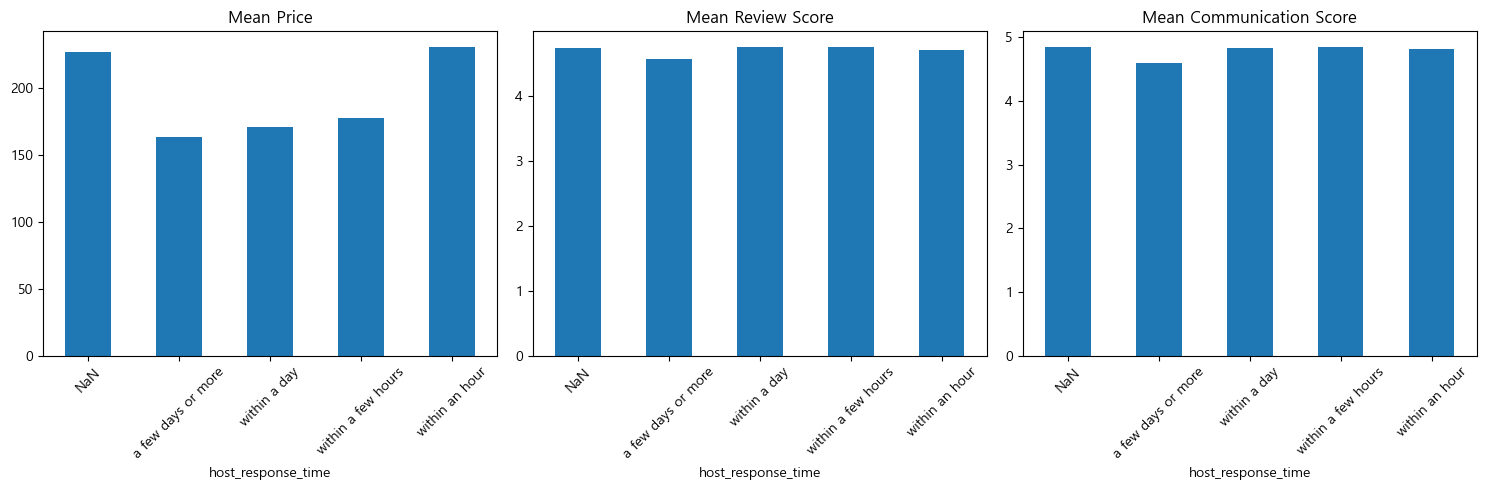

In [4]:
#막대그래프로 시각화
fig, axes = plt.subplots(1, 3, figsize=(15,5))

host_response_price_df['mean_price'].plot(kind='bar', ax=axes[0])
axes[0].set_title('Mean Price')
axes[0].tick_params(axis='x', rotation=45)

host_response_price_df['mean_review_score'].plot(kind='bar', ax=axes[1])
axes[1].set_title('Mean Review Score')
axes[1].tick_params(axis='x', rotation=45)

host_response_price_df['mean_communication_score'].plot(kind='bar', ax=axes[2])
axes[2].set_title('Mean Communication Score')
axes[2].tick_params(axis='x', rotation=45)



plt.tight_layout()
plt.show()

In [5]:
#가격과 호스트 관련 컬럼과의 상관관계
host_num_cols = ['host_response_rate','host_acceptance_rate','host_listings_count','host_total_listings_count']

price_host_cols = ['price','log_price'] + host_num_cols

display(df[price_host_cols].corr()['price'])

#host_listings_count          0.146147
#host_total_listings_count    0.160511

price                        1.000000
log_price                    0.570605
host_response_rate           0.042325
host_acceptance_rate         0.006481
host_listings_count          0.146147
host_total_listings_count    0.160511
Name: price, dtype: float64

In [6]:
display(df[price_host_cols].corr()['log_price'])


price                        0.570605
log_price                    1.000000
host_response_rate           0.082527
host_acceptance_rate         0.092940
host_listings_count          0.348725
host_total_listings_count    0.359894
Name: log_price, dtype: float64

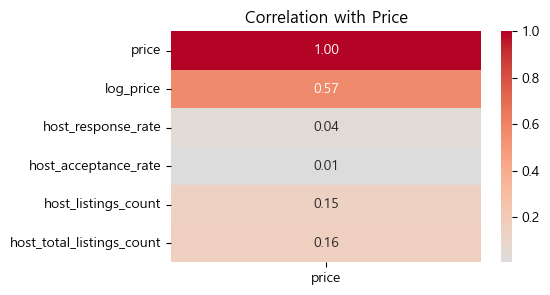

In [7]:
plt.figure(figsize=(5,3))

sns.heatmap(
    df[price_host_cols].corr()[['price']],
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    center=0
)

plt.title("Correlation with Price")
plt.show()

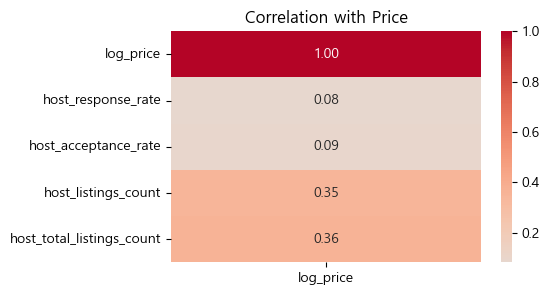

In [8]:
plt.figure(figsize=(5,3))

sns.heatmap(
    df[price_host_cols].corr()[1:][['log_price']],
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    center=0
)

plt.title("Correlation with Price")
plt.show()

In [9]:
#슈퍼호스트 여부와 가격
superhost_price_df = df.groupby('host_is_superhost').agg(
    price_mean = ('price','mean'),
    superhost_count = ('id','count'),
     occupied_date = ('estimated_occupancy_l365d','mean')
)
superhost_price_df.round(2)

,price_mean,superhost_count,occupied_date
host_is_superhost,,,
False,227.76,15799,43.44
True,178.78,6135,141.79


count    17915.000000
mean         0.930423
std          0.192891
min          0.000000
25%          0.990000
50%          1.000000
75%          1.000000
max          1.000000
Name: host_response_rate, dtype: float64

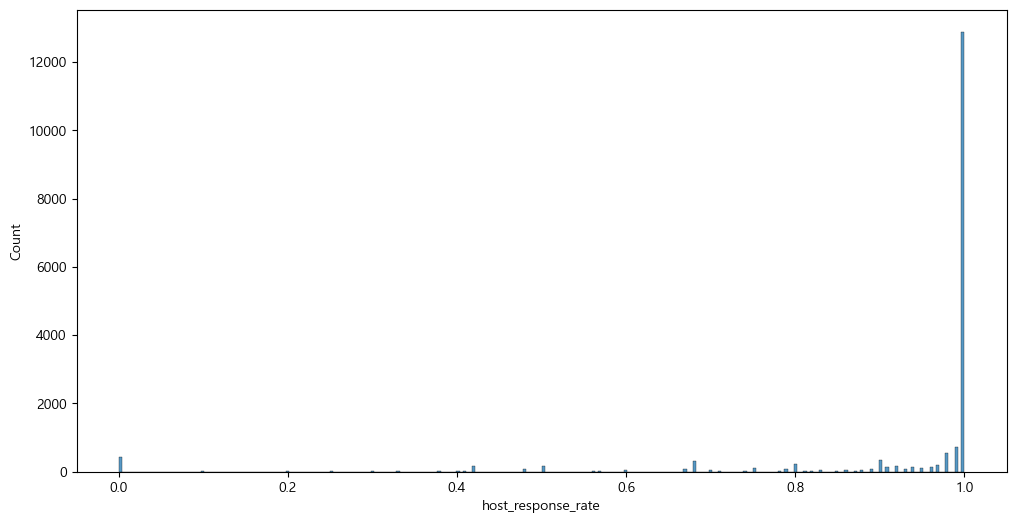

In [10]:
sns.histplot(df['host_response_rate'])
df['host_response_rate'].describe()

<Axes: xlabel='host_acceptance_rate', ylabel='Count'>

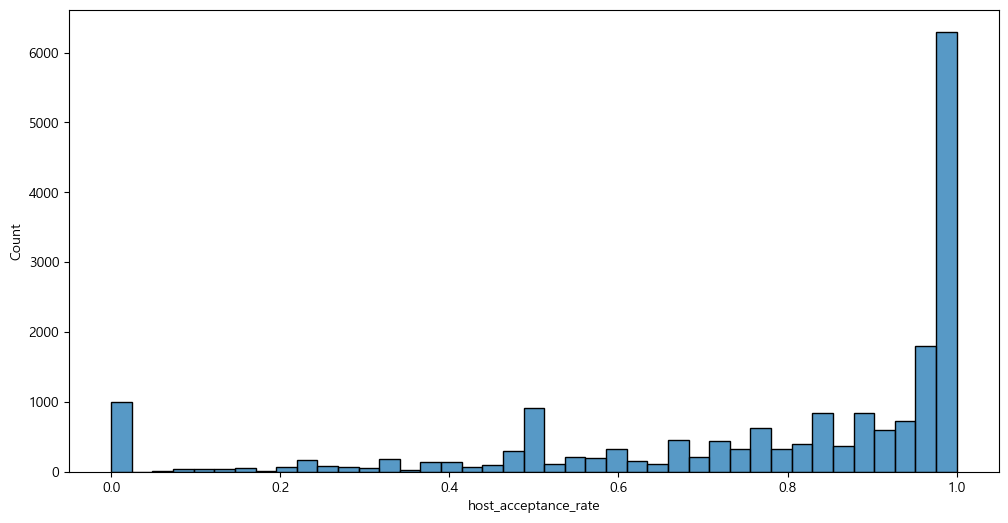

In [11]:
df['host_acceptance_rate'].describe()
sns.histplot(df['host_acceptance_rate'])

# neighbourhood_group_cleansed - 가격 관련

In [12]:
group_price_df = df.groupby('neighbourhood_group_cleansed').agg(
    price_mean = ('price','mean'),
    price_median = ('price','median'),
    group_count = ('id','count'),
     occupied_days = ('estimated_occupancy_l365d','mean')
)
group_price_df.round(2)

,price_mean,price_median,group_count,occupied_days
neighbourhood_group_cleansed,,,,
Bronx,121.81,90.0,912,62.17
Brooklyn,169.65,124.0,7455,79.22
Manhattan,286.34,189.0,10205,64.61
Queens,126.24,96.0,3420,78.06
Staten Island,128.34,99.5,316,72.23


In [13]:
#가격과 그룹별
display(group_price_df['price_mean'])

neighbourhood_group_cleansed
Bronx            121.807018
Brooklyn         169.646680
Manhattan        286.343557
Queens           126.239474
Staten Island    128.344937
Name: price_mean, dtype: float64

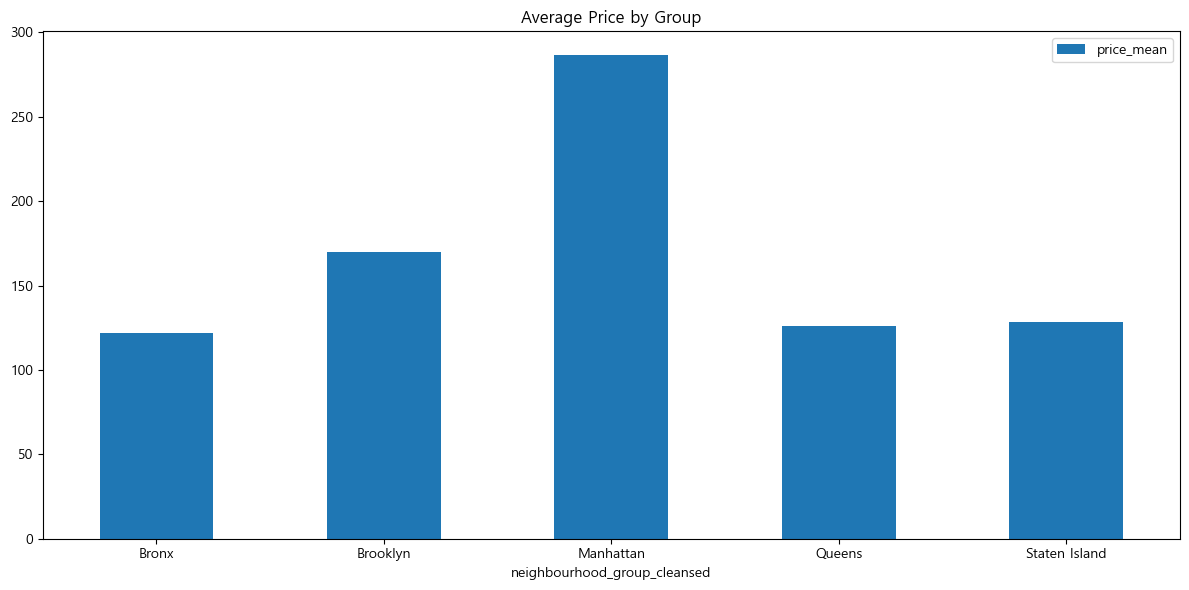

In [14]:
#도시 별 가격 정보
group_price_df['price_mean'].plot(kind='bar', rot = 0,title='Average Price by Group')

plt.tight_layout()
plt.legend()
plt.show()

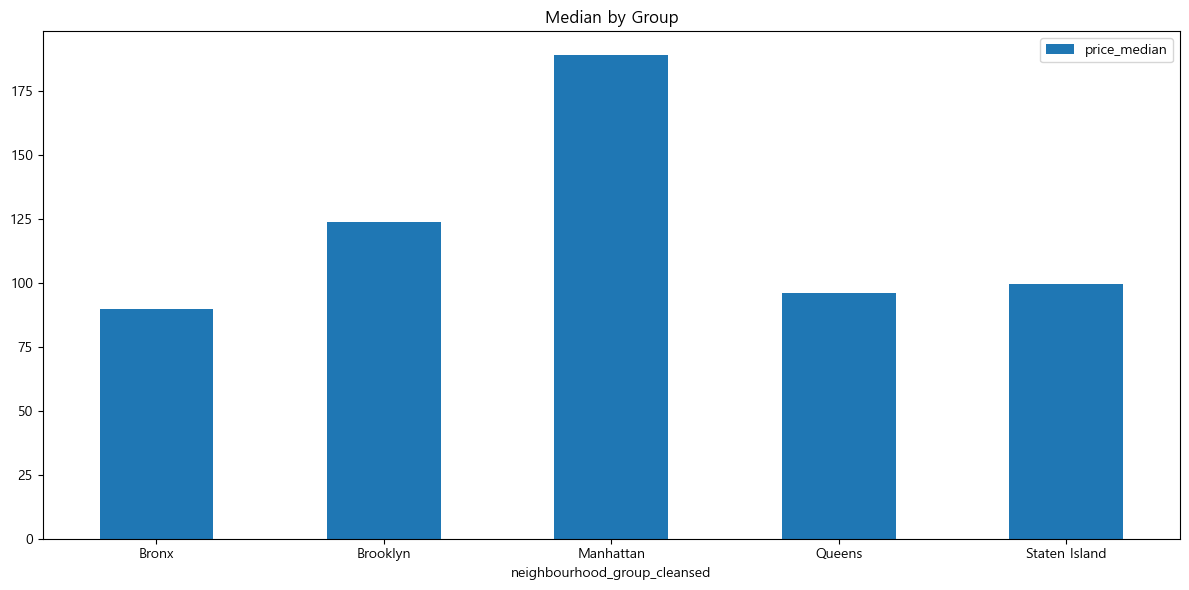

In [15]:
group_price_df['price_median'].plot(kind='bar', rot = 0,title='Median by Group')
plt.tight_layout()
plt.legend()
plt.show()

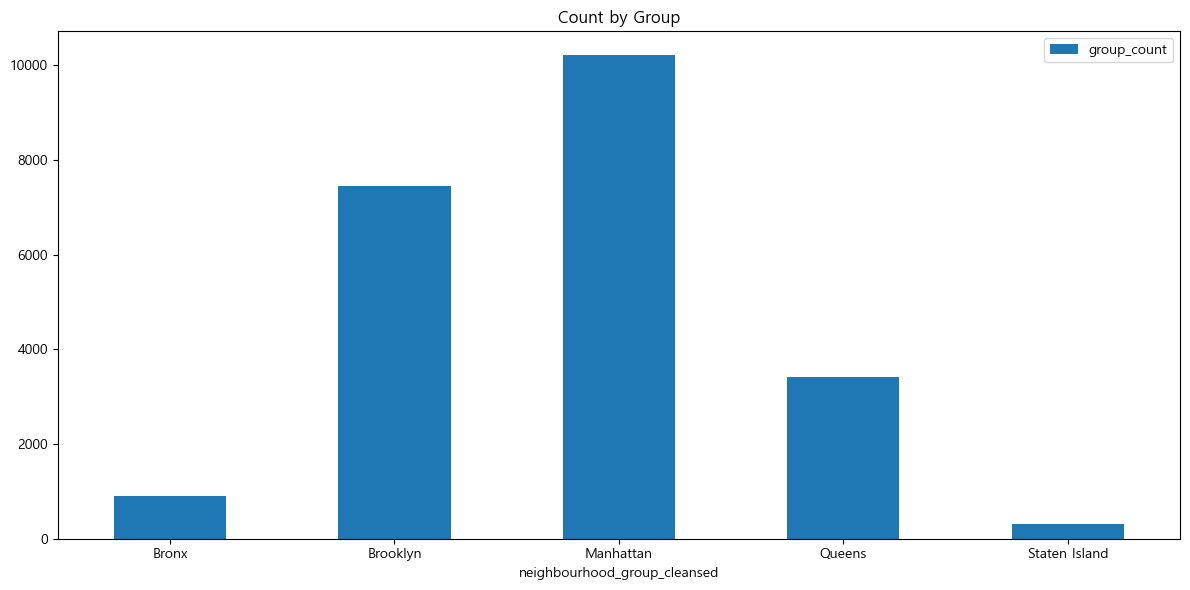

In [16]:
group_price_df['group_count'].plot(kind='bar', rot = 0,title='Count by Group')
plt.tight_layout()
plt.legend()
plt.show()


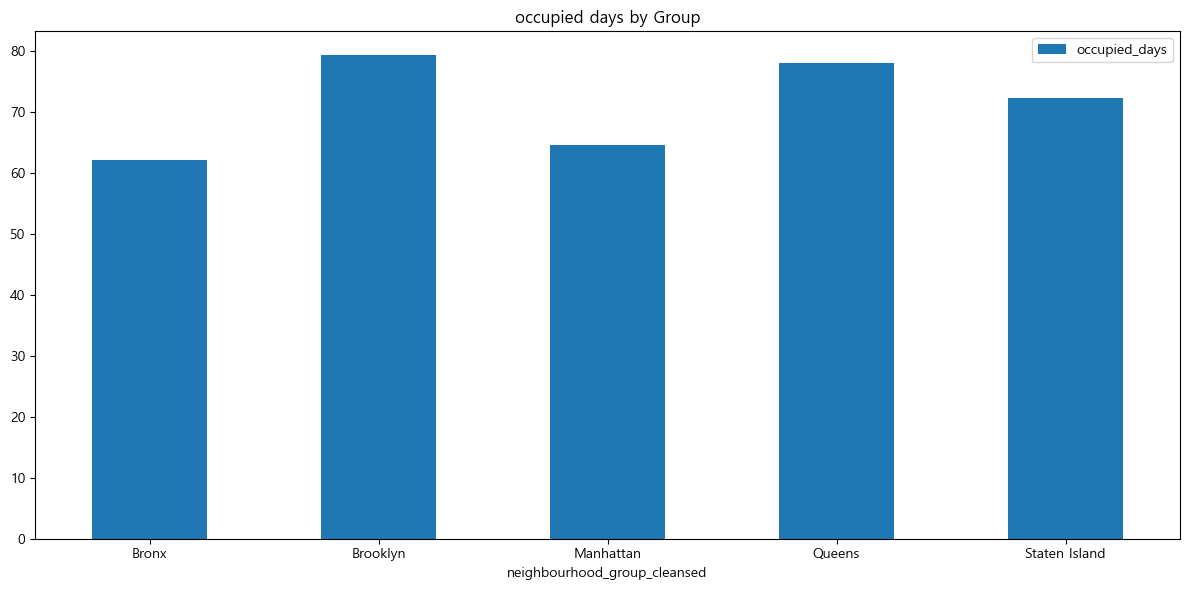

In [17]:
group_price_df['occupied_days'].plot(kind='bar', rot = 0,title='occupied days by Group')
plt.tight_layout()
plt.legend()
plt.show()


Brooklyn shapiro (p-value): 6.849273285663981e-97
Manhattan shapiro (p-value): 1.1739086546093911e-108
Queens shapiro (p-value): 7.168164116467101e-73
Bronx shapiro (p-value): 4.3287071407295247e-54
Staten Island shapiro (p-value): 2.5394791484847276e-29


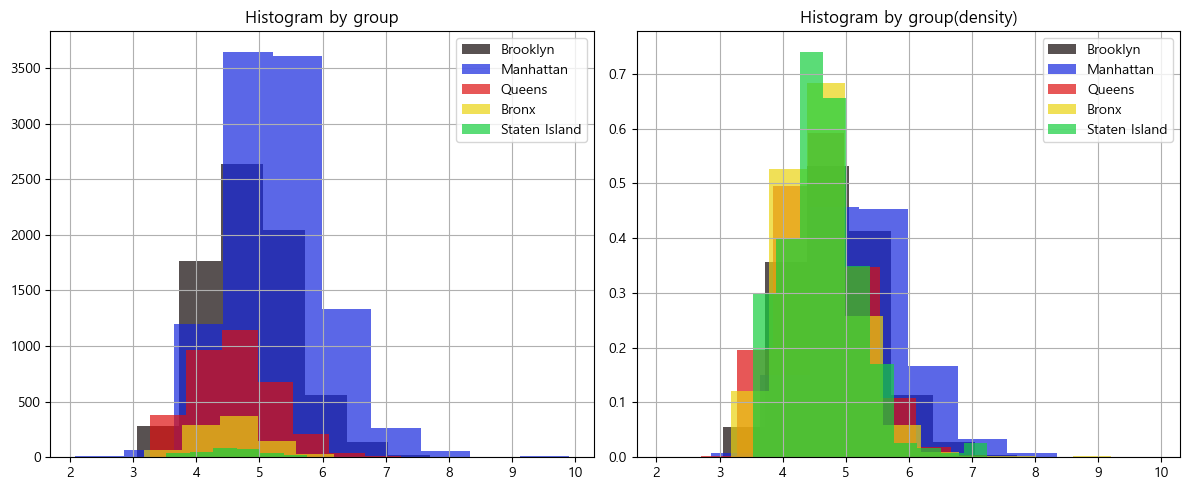

In [38]:
from scipy import stats
import numpy as np
group_cols = df['neighbourhood_group_cleansed'].unique()
group_cols
color_cols = ["#110707","#1626DE","#DE1010","#EAD410","#16CE3E"]

for i in group_cols:
    print(f'{i} shapiro (p-value): {stats.shapiro(df[df['neighbourhood_group_cleansed']==i]['price'])[1]}')
    
    
fig, ax = plt.subplots(1,2,figsize=(12,5))

for idx, g in enumerate(group_cols):
    group_price = df[df["neighbourhood_group_cleansed"] == g]["price"]
    group_price = np.log1p(group_price)
    group_price.hist(color=color_cols[idx],ax=ax[0], label=g, alpha = 0.7)
    
    
for idx, g in enumerate(group_cols):
    group_price = df[df["neighbourhood_group_cleansed"] == g]["price"]
    group_price = np.log1p(group_price)
    group_price.hist(color=color_cols[idx],ax=ax[1], label=g, alpha = 0.7, density=True)

ax[0].set_title('Histogram by group')
ax[1].set_title('Histogram by group(density)')

ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()
#y축을 비율로



# room type 별 price

In [19]:
room_price_df = df.groupby('room_type').agg(
    price_mean = ('price','mean'),
    price_median = ('price', 'median'),
    room_count = ('id','count'),
     occupied_days = ('estimated_occupancy_l365d','mean')
)

room_price_df

,price_mean,price_median,room_count,occupied_days
room_type,,,,
Entire home/apt,265.344757,190.0,12664,72.955701
Hotel room,527.634409,403.0,372,12.591398
Private room,130.763009,81.0,9186,71.979643
Shared room,144.662791,79.0,86,76.988372


In [20]:
#방 타입 별 평균 가격
display(room_price_df['price_mean'])

room_type
Entire home/apt    265.344757
Hotel room         527.634409
Private room       130.763009
Shared room        144.662791
Name: price_mean, dtype: float64

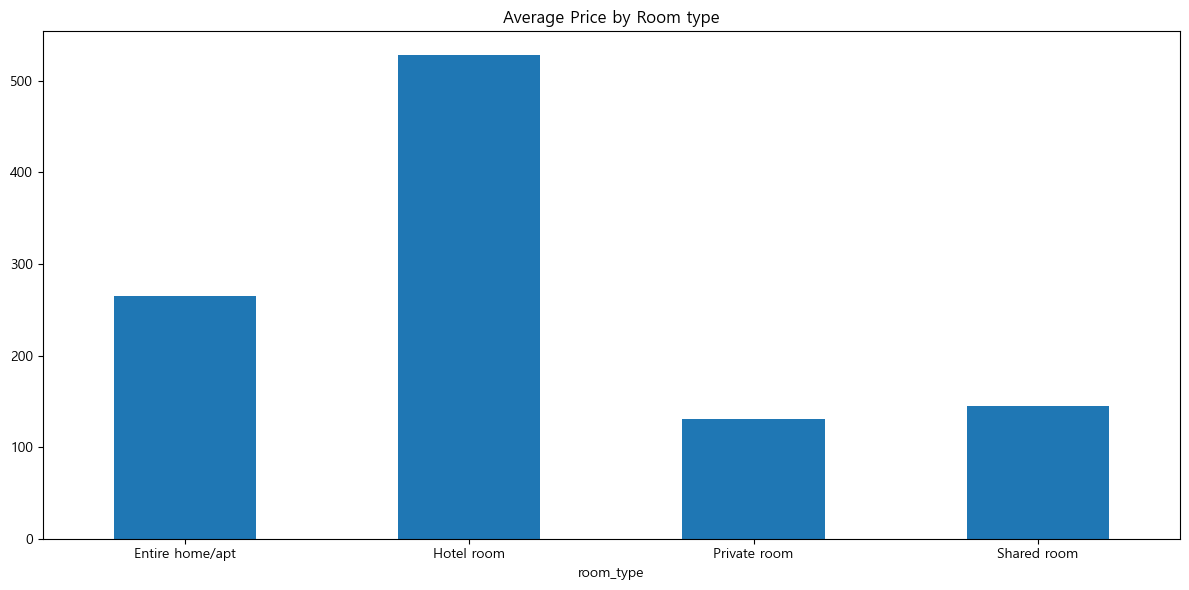

In [21]:
room_price_df['price_mean'].plot(kind='bar',rot = 0, title ='Average Price by Room type')
plt.tight_layout()

In [22]:
#방 타입별 수

display(room_price_df['room_count'])

room_type
Entire home/apt    12664
Hotel room           372
Private room        9186
Shared room           86
Name: room_count, dtype: int64

<Axes: title={'center': 'Median by Room type'}, xlabel='room_type'>

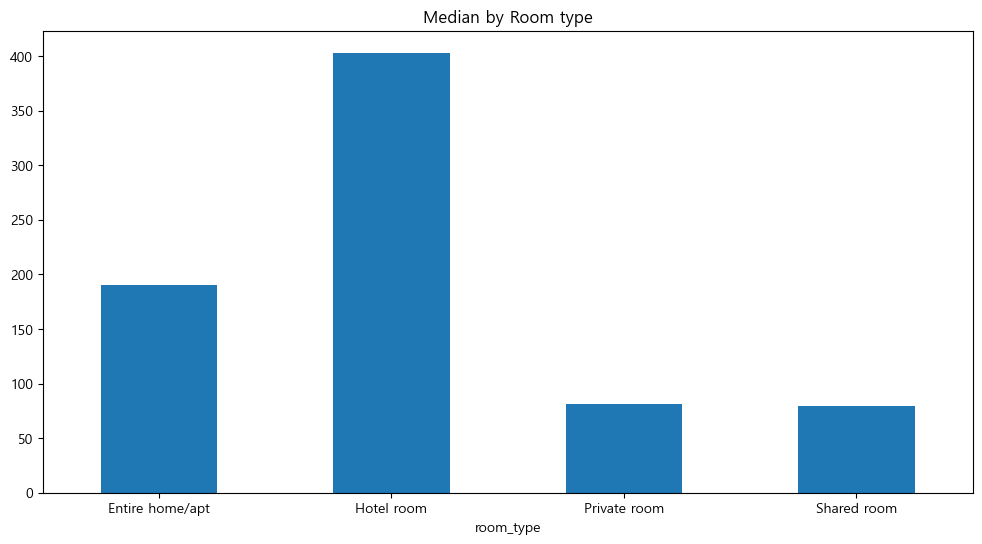

In [23]:
room_price_df['price_median'].plot(kind='bar', rot = 0, title = 'Median by Room type')

<Axes: title={'center': 'Count by Room type'}, xlabel='room_type'>

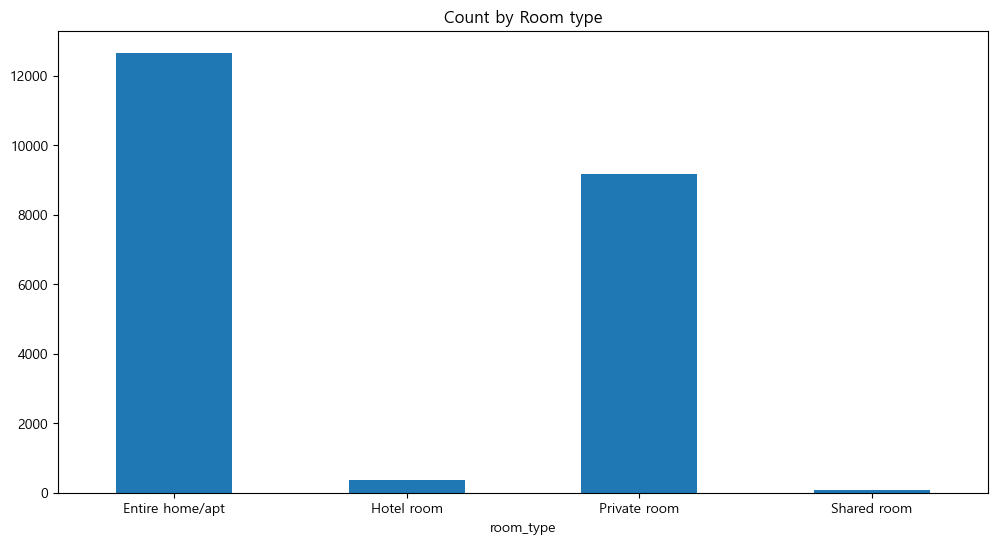

In [24]:
room_price_df['room_count'].plot(kind='bar', rot = 0, title = 'Count by Room type')

<Axes: title={'center': 'occupied days by Room type'}, xlabel='room_type'>

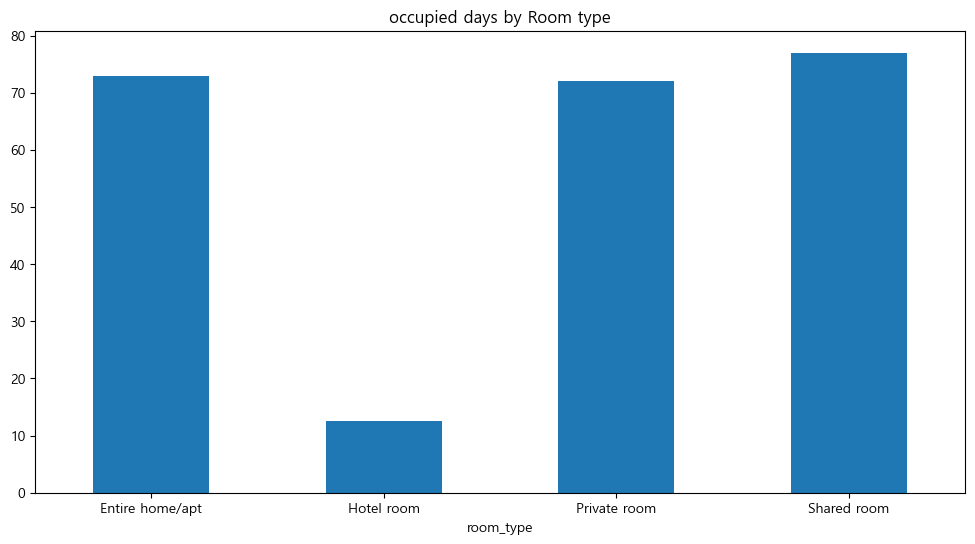

In [25]:
room_price_df['occupied_days'].plot(kind='bar', rot = 0, title = 'occupied days by Room type')

Brooklyn shapiro (p-value): nan
Manhattan shapiro (p-value): nan
Queens shapiro (p-value): nan
Bronx shapiro (p-value): nan
Staten Island shapiro (p-value): nan


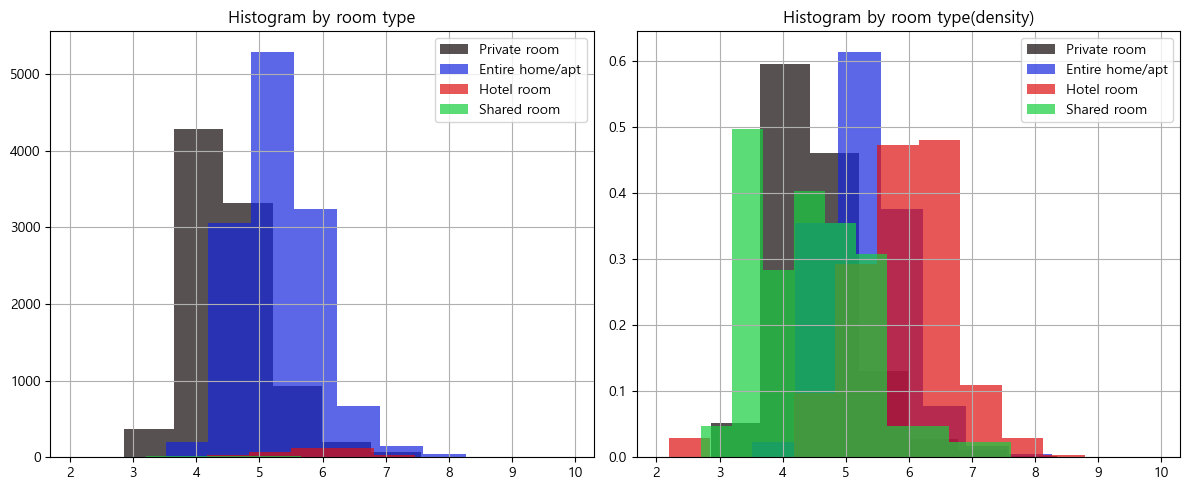

In [39]:
room_cols = df['room_type'].unique()
room_cols
color_cols = ["#110707","#1626DE","#DE1010","#16CE3E"]

for i in group_cols:
    print(f'{i} shapiro (p-value): {stats.shapiro(df[df['room_type']==i]['price'])[1]}')
    
    
fig, ax = plt.subplots(1,2,figsize=(12,5))

for idx, g in enumerate(room_cols):
    room_price = df[df["room_type"] == g]["price"]
    room_price = np.log1p(room_price)
    room_price.hist(color=color_cols[idx],ax=ax[0], label=g, alpha = 0.7)

for idx, g in enumerate(room_cols):
    room_price = df[df["room_type"] == g]["price"]
    room_price = np.log1p(room_price)
    room_price.hist(color=color_cols[idx],ax=ax[1], label=g, alpha = 0.7, density = True)

ax[0].set_title('Histogram by room type')
ax[1].set_title('Histogram by room type(density)')
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

# Place to Stay 항목과 가격 관 상관관계 찍어보기

In [27]:
place_num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds']

place_num_price_cols = ['price','log_price'] + place_num_cols

df[place_num_price_cols].corr()['price']

price           1.000000
log_price       0.570605
accommodates    0.283324
bathrooms       0.217298
bedrooms        0.177070
beds            0.197385
Name: price, dtype: float64

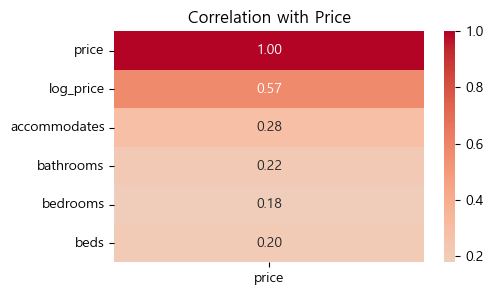

In [28]:
plt.figure(figsize=(5,3))

sns.heatmap(
    df[place_num_price_cols].corr()[['price']],
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    center=0
)

plt.title("Correlation with Price")
plt.show()

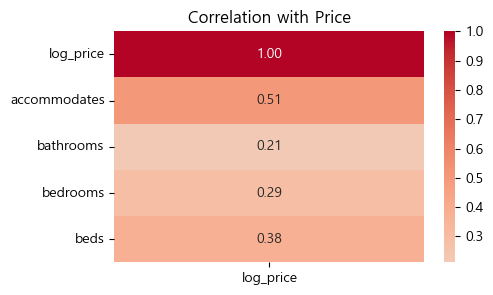

In [29]:
plt.figure(figsize=(5,3))

sns.heatmap(
    df[place_num_price_cols].corr()[1:][['log_price']],
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    center=0
)

plt.title("Correlation with Price")
plt.show()

In [30]:
review_score_cols = ['number_of_reviews','reviews_per_month','review_scores_rating',
                     'review_scores_cleanliness','review_scores_communication',
                     'number_of_reviews_ltm', 'number_of_reviews_l30d', 'number_of_reviews_ly',
                     'review_scores_accuracy', 'review_scores_cleanliness','review_scores_checkin',
                     'review_scores_communication', 'review_scores_location', 'review_scores_value']

price_review_score_cols = ['price'] + review_score_cols

df[price_review_score_cols].corr()['price']

price                          1.000000
number_of_reviews             -0.051742
reviews_per_month             -0.011764
review_scores_rating           0.043957
review_scores_cleanliness      0.055828
review_scores_communication    0.023769
number_of_reviews_ltm         -0.020382
number_of_reviews_l30d        -0.013426
number_of_reviews_ly          -0.020200
review_scores_accuracy         0.034710
review_scores_cleanliness      0.055828
review_scores_checkin          0.022294
review_scores_communication    0.023769
review_scores_location         0.085849
review_scores_value            0.012483
Name: price, dtype: float64

In [31]:
df['estimated_occupancy_l365d'].describe()

count    22308.000000
mean        71.562713
std         96.622429
min          0.000000
25%          0.000000
50%          0.000000
75%        120.000000
max        255.000000
Name: estimated_occupancy_l365d, dtype: float64

In [32]:
bookable_df = df.groupby('instant_bookable').agg(
    price_mean = ('price','mean'),
    price_median = ('price','median'),
    cnt = ('id','count')
)
bookable_df.round(2)

,price_mean,price_median,cnt
instant_bookable,,,
False,186.68,126.0,16618
True,293.15,200.0,5690
